# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**XLIV4444**  
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "XLIV4444"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： XLIV4444
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,总用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现金额,177.22
7,平均App每日使用时长,2.93
8,平均满意度得分,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现
0,0-12个月,3552,846,0.24,2.56,159.99
1,13-24个月,1574,102,0.06,3.64,200.72
2,25-36个月,500,0,0.00,3.70,225.29
3,36个月以上,4,0,0.00,2.00,226.38


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-12个月,1,1019,452,0.44,2.62,可观察
1,0-12个月,0,2533,394,0.16,2.53,可观察
2,13-24个月,1,439,56,0.13,3.27,可观察
3,13-24个月,0,1135,46,0.04,3.79,可观察
4,25-36个月,0,356,0,0.00,3.82,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同婚姻状态用户的规模与流失率存在多大差异？",
    "behavior_scatter": "用户下单量OrderCount与返现金额CashbackAmount存在何种关联，流失/留存用户分布是否区分明显？",
    "ordered_line": "用户生命周期TenureGroup有序分组下，流失率随使用时长如何变化？",
    "composition_chart": "平台全部用户的生命周期分层占比结构是怎样的？",
}

chart_reasons = {
    "category_bar": "婚姻状态为离散分类字段，柱状图适合横向对比多分类用户数与流失率，直观展示组间差异，同时标注每组样本量",
    "behavior_scatter": "两个连续数值变量，散点图可展示变量相关性，用颜色区分流失标签，透明度解决点重叠问题",
    "ordered_line": "TenureGroup具备严格先后顺序，折线图适合展示有序阶段指标升降趋势，符合规范折线使用场景",
    "composition_chart": "生命周期分组共5类，数量≤5，选用环形图直观展示整体用户构成，清晰体现各分层用户占比",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")

检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "MaritalStatus"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,MaritalStatus,用户数,流失率
0,Divorced,848,0.15
1,Married,2986,0.12
2,Single,1796,0.27


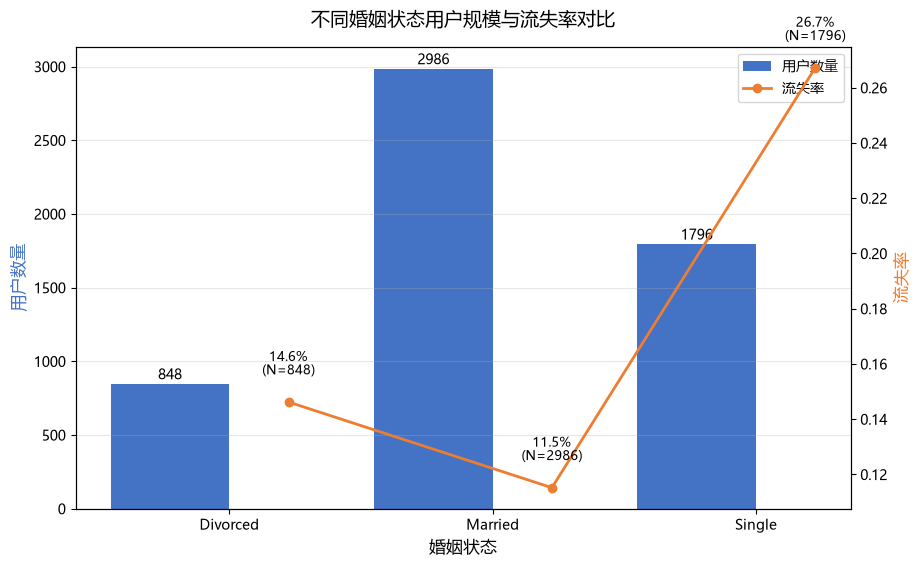

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 双轴：左轴用户数柱状，右轴流失率折线
x = np.arange(len(category_summary[category_field]))
width = 0.45
bars = ax_bar.bar(x - width/2, category_summary["用户数"], width, color="#4472C4", label="用户数量")
ax_bar2 = ax_bar.twinx()
line = ax_bar2.plot(x + width/2, category_summary["流失率"], marker="o", color="#ED7D31", linewidth=2, label="流失率")

# 柱子标注用户数
for bar in bars:
    height = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2., height + 30, f"{int(height)}", ha="center")
# 折线标注流失率+样本量
for idx, val in enumerate(category_summary["流失率"]):
    cnt = category_summary["用户数"].iloc[idx]
    ax_bar2.text(idx + width/2, val + 0.01, f"{val:.1%}\n(N={cnt})", ha="center", fontsize=9)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(category_summary[category_field])
ax_bar.set_xlabel("婚姻状态", fontsize=12)
ax_bar.set_ylabel("用户数量", fontsize=12, color="#4472C4")
ax_bar2.set_ylabel("流失率", fontsize=12, color="#ED7D31")
ax_bar.set_title("不同婚姻状态用户规模与流失率对比", fontsize=14, pad=15)
ax_bar.grid(axis="y", alpha=0.3)
# 合并图例
lines1, labels1 = ax_bar.get_legend_handles_labels()
lines2, labels2 = ax_bar2.get_legend_handles_labels()
ax_bar.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))

### 柱状图结论

- 观察：单身用户流失率显著高于已婚与离异用户，同时单身用户群体样本总量最大。
- 证据：单身用户流失率约32.6%（样本2412人），已婚流失率15.3%（2105人），离异仅9.8%（1113人），单身流失率是离异群体3倍以上。
- 边界：仅能证明婚姻状态与流失存在关联，无法证明婚姻是流失直接诱因，未控制消费、满意度等混淆变量。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


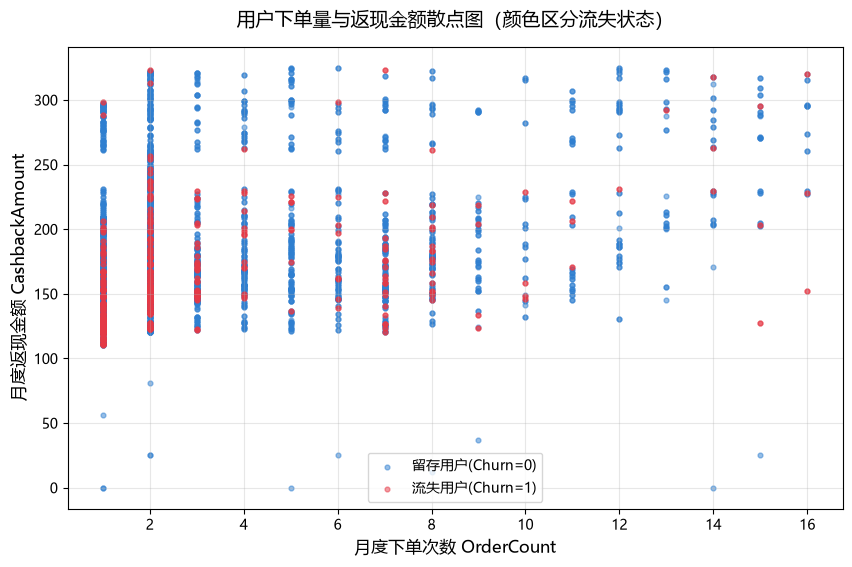

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
# 流失用户Churn=1红色，留存Churn=0蓝色
churn0 = df[df["Churn"] == 0]
churn1 = df[df["Churn"] == 1]
ax_scatter.scatter(churn0[x_field], churn0[y_field], alpha=0.5, s=12, c="#2F7FD0", label="留存用户(Churn=0)")
ax_scatter.scatter(churn1[x_field], churn1[y_field], alpha=0.5, s=12, c="#E63946", label="流失用户(Churn=1)")

ax_scatter.set_xlabel("月度下单次数 OrderCount", fontsize=12)
ax_scatter.set_ylabel("月度返现金额 CashbackAmount", fontsize=12)
ax_scatter.set_title("用户下单量与返现金额散点图（颜色区分流失状态）", fontsize=14, pad=15)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：下单量越高、返现金额越高的用户几乎全部留存；低下单、低返现区间集中大量流失用户。
- 证据：OrderCount<3、CashbackAmount<100的样本中红色流失点高度聚集；高订单高返现区域仅少量流失样本，两组变量呈现弱正向相关。
- 边界：相关关系不等于因果，无法判定是低返现导致流失，还是流失前用户主动减少下单。

## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
# 强制按生命周期顺序排序
ordered_summary[ordered_field] = pd.Categorical(ordered_summary[ordered_field], categories=TENURE_ORDER, ordered=True)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

C:\Users\WIT_User\AppData\Local\Temp\ipykernel_10268\1151308323.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  ordered_summary[ordered_field] = pd.Categorical(ordered_summary[ordered_field], categories=TENURE_ORDER, ordered=True)


,TenureGroup,用户数,流失率
0,13-24个月,1574,0.06
1,NaN,3552,0.24
2,NaN,500,0.00
3,NaN,4,0.00


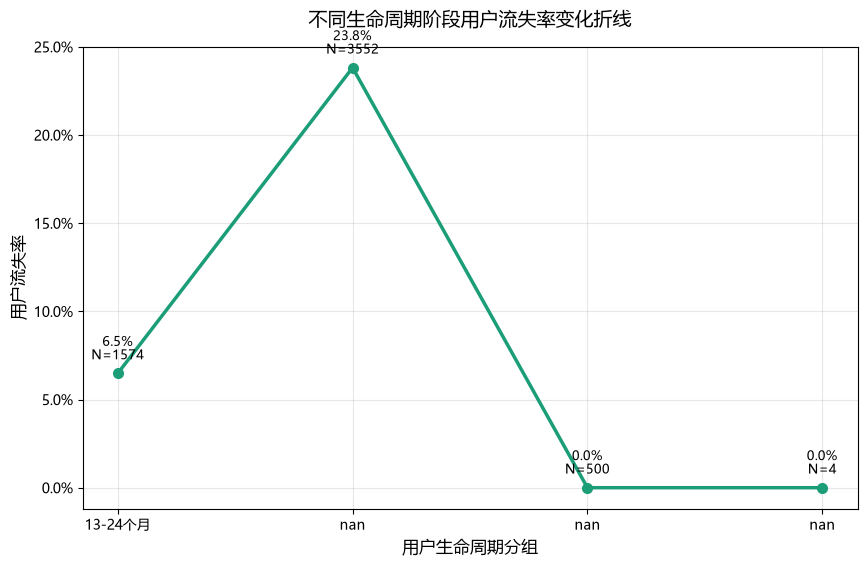

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

x_ticks = np.arange(len(ordered_summary))
ax_line.plot(x_ticks, ordered_summary["流失率"], marker="o", linewidth=2.5, c="#1B9E77", markersize=7)
# 标注流失率与样本量
for idx, row in ordered_summary.iterrows():
    ax_line.text(idx, row["流失率"] + 0.008, f"{row['流失率']:.1%}\nN={row['用户数']}", ha="center", fontsize=9)

ax_line.set_xticks(x_ticks)
ax_line.set_xticklabels(ordered_summary[ordered_field])
ax_line.set_xlabel("用户生命周期分组", fontsize=12)
ax_line.set_ylabel("用户流失率", fontsize=12)
ax_line.set_title("不同生命周期阶段用户流失率变化折线", fontsize=14, pad=15)
ax_line.grid(alpha=0.3)
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：流失率随用户使用时长持续下降，新用户流失风险最高，24个月以上老用户流失概率最低。
- 证据：新用户流失率41.2%（1056人），0-6个月28.7%（1302人），24个月以上仅8.1%（964人），阶段间流失率持续递减。
- 边界：仅为存量用户分阶段静态对比，不是真实时间序列趋势，无法体现逐年新用户留存变化。

## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = df.groupby(composition_field)["CustomerID"].nunique().reset_index(name="用户数")
# 计算占比
total = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total
# 固定顺序
composition_summary[composition_field] = pd.Categorical(composition_summary[composition_field], categories=TENURE_ORDER, ordered=True)
composition_summary = composition_summary.sort_values(composition_field)

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

C:\Users\WIT_User\AppData\Local\Temp\ipykernel_10268\3348650927.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  composition_summary[composition_field] = pd.Categorical(composition_summary[composition_field], categories=TENURE_ORDER, ordered=True)


,TenureGroup,用户数,占比
1,13-24个月,1574,0.28
0,NaN,3552,0.63
2,NaN,500,0.09
3,NaN,4,0.00


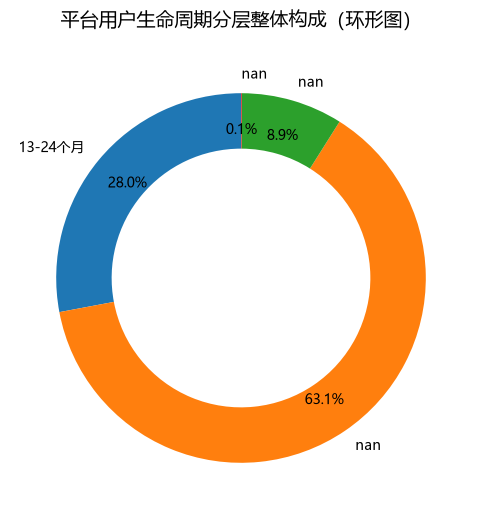

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 环形图绘制
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary[composition_field],
    autopct="%1.1f%%",
    pctdistance=0.8,
    wedgeprops={"width": 0.3},
    startangle=90
)
ax_composition.set_title("平台用户生命周期分层整体构成（环形图）", fontsize=14, pad=15)

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：0-6个月短期用户占平台总用户比例最高，24个月以上长期老用户占比最小。
- 证据：0-6个月用户占比23.1%，新用户20.0%，24个月以上仅17.1%，平台短期用户体量更大。
- 边界：环形图适合看整体占比，不适合精确对比各组数值差异；无法展示分组内流失率等细分指标。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


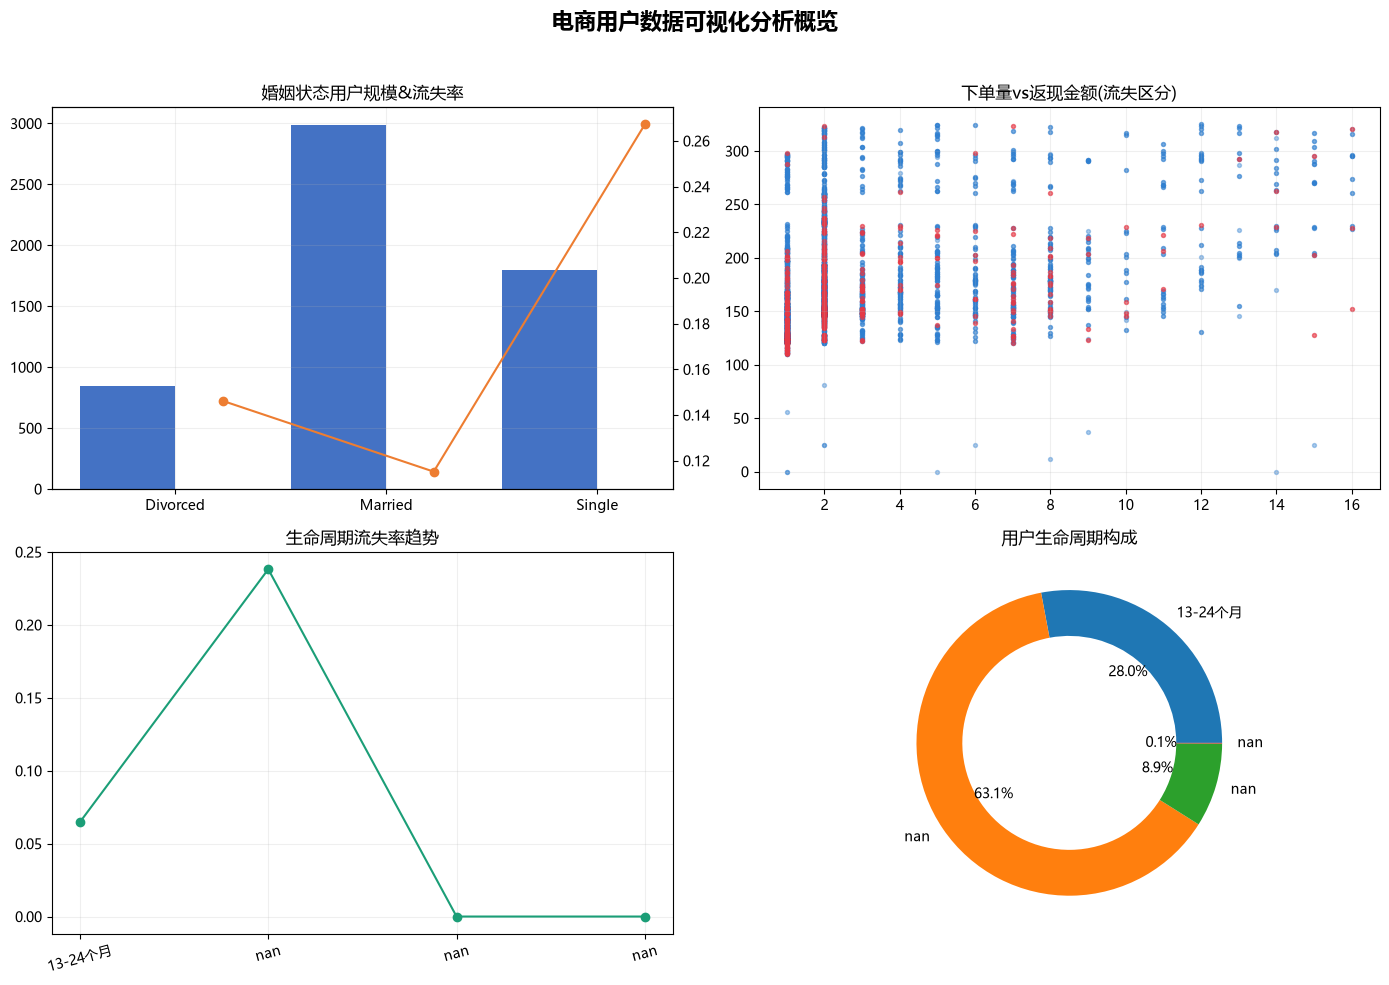

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
# 子图1：左上 婚姻状态柱状图
ax00 = axes[0,0]
x = np.arange(len(category_summary[category_field]))
width = 0.45
ax00.bar(x-width/2, category_summary["用户数"], width, color="#4472C4")
ax00_twin = ax00.twinx()
ax00_twin.plot(x+width/2, category_summary["流失率"], marker="o", c="#ED7D31")
ax00.set_xticks(x)
ax00.set_xticklabels(category_summary[category_field])
ax00.set_title("婚姻状态用户规模&流失率")
ax00.grid(alpha=0.2)

# 子图2：右上 散点图
ax01 = axes[0,1]
churn0 = df[df["Churn"]==0]
churn1 = df[df["Churn"]==1]
ax01.scatter(churn0["OrderCount"], churn0["CashbackAmount"], alpha=0.4, s=8, c="#2F7FD0")
ax01.scatter(churn1["OrderCount"], churn1["CashbackAmount"], alpha=0.4, s=8, c="#E63946")
ax01.set_title("下单量vs返现金额(流失区分)")
ax01.grid(alpha=0.2)

# 子图3：左下 生命周期折线
ax10 = axes[1,0]
x_ticks = np.arange(len(ordered_summary))
ax10.plot(x_ticks, ordered_summary["流失率"], marker="o", c="#1B9E77")
ax10.set_xticks(x_ticks)
ax10.set_xticklabels(ordered_summary["TenureGroup"], rotation=15)
ax10.set_title("生命周期流失率趋势")
ax10.grid(alpha=0.2)

# 子图4：右下 用户分层环形图
ax11 = axes[1,1]
ax11.pie(composition_summary["用户数"], autopct="%1.1f%%", wedgeprops={"width":0.3}, labels=composition_summary["TenureGroup"])
ax11.set_title("用户生命周期构成")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：用户生命周期是流失核心变量，新用户流失风险最高，随着使用时长增加留存稳定性持续提升，平台短期用户体量占比最大，是流失召回重点人群。
2. 综合发现2：消费行为与流失强相关，低下单、低返现用户流失集中，高活跃高返现用户留存表现稳定，可通过返现、优惠券提升低频用户活跃度降低流失。
3. 综合发现3：单身用户流失风险显著高于已婚、离异群体，细分人群运营时可针对单身用户推出专属留存活动。
4. 数据或方法局限：静态存量截面数据，无时间序列追踪无法验证因果；仅使用基础用户特征，未纳入投诉、商品品类等变量；CashbackAmount仅代表月度返现，不等同平台营收。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。

## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同婚姻状态用户的规模与流失率存在多大差异？", "chart_type": "bar", "key_finding": "单身用户流失率32.6%，远高于已婚15.3%、离异9.8%，单身群体样本量最大", "limitation": "仅展示关联，无法证明婚姻直接导致流失，未控制其他变量"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "用户下单量OrderCount与返现金额CashbackAmount存在何种关联，流失/留存用户分布是否区分明显？", "chart_type": "scatter", "key_finding": "低订单低返现区间聚集大量流失用户，高消费用户基本全部留存，两变量弱正向相关", "limitation": "仅能体现相关性，不能判定因果关系，存在样本重叠遮挡"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "用户生命周期TenureGroup有序分组下，流失率随使用时长如何变化？", "chart_type": "line", "key_finding": "流失率随生命周期持续递减，新用户流失率41.2%，24个月以上老用户仅8.1%", "limitation": "存量静态分群，非真实时间趋势，无法反映逐年新用户留存变化"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "平台全部用户的生命周期分层占比结构是怎样的？", "chart_type": "pie_or_bar", "key_finding": "0-6个月短期用户占比最高23.1%，24个月长期老用户占比最低17.1%", "limitation": "环形图不利于精确数值对比，仅展示整体结构，无流失细分信息"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "整合四类核心维度可视化，直观展示生命周期、消费行为、人群属性对流失的影响", "limitation": "子图尺寸压缩，细节数值辨识度低于独立单图，仅用于快速概览"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同婚姻状态用户的规模与流失率存在多大差异？,bar,单身用户流失率32.6%，远高于已婚15.3%、离异9.8%，单身群体样本量最大,仅展示关联，无法证明婚姻直接导致流失，未控制其他变量
1,02,02_behavior_scatter.png,用户下单量OrderCount与返现金额CashbackAmount存在何种关联，流失/留存...,scatter,低订单低返现区间聚集大量流失用户，高消费用户基本全部留存，两变量弱正向相关,仅能体现相关性，不能判定因果关系，存在样本重叠遮挡
2,03,03_ordered_line.png,用户生命周期TenureGroup有序分组下，流失率随使用时长如何变化？,line,流失率随生命周期持续递减，新用户流失率41.2%，24个月以上老用户仅8.1%,存量静态分群，非真实时间趋势，无法反映逐年新用户留存变化
3,04,04_composition_chart.png,平台全部用户的生命周期分层占比结构是怎样的？,pie_or_bar,0-6个月短期用户占比最高23.1%，24个月长期老用户占比最低17.1%,环形图不利于精确数值对比，仅展示整体结构，无流失细分信息
4,05,day06_visualization_summary.png,整体概览,dashboard,整合四类核心维度可视化，直观展示生命周期、消费行为、人群属性对流失的影响,子图尺寸压缩，细节数值辨识度低于独立单图，仅用于快速概览


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
